# Week 09 - 하이퍼파라미터 튜닝 실습
**빅데이터 응용 실습 | Hyperparameter Tuning Practice**

---

### 📌 학습 목표
- GridSearchCV를 활용한 하이퍼파라미터 튜닝
- RandomizedSearchCV를 활용한 하이퍼파라미터 튜닝
- 최적 모델 성능 비교 및 평가

## 1. 라이브러리 임포트

In [9]:
import numpy as np
import pandas as pd
import time

from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import classification_report, f1_score

pd.set_option('display.max_columns', 200)
print('Ready')

Ready


1) 데이터 처리 라이브러리
- numpy: 수치 연산 및 배열 처리
- pandas: 데이터프레임 조작 및 분석
- time: 코드 실행 시간 측정

2) 모델 및 전처리 라이브러리
- sklearn: 머신러닝 모델, 교차검증
- StandardScaler: 특성 스케일링
- Pipeline: 전처리와 모델 통합

3) 평가 지표 및 설정 완료
- classification_report: 성능 보고서
- f1_score: F1 점수 계산

In [10]:
df = pd.read_csv('week9_hyperparameter_tuning_practice.csv')
x = df.drop(columns=['churn'])
y = df['churn']

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.3, random_state = 42, stratify = y
)

print(y_train.value_counts(normalize=True).round(3))
print(y_test.value_counts(normalize=True).round(3))

churn
0    0.75
1    0.25
Name: proportion, dtype: float64
churn
0    0.75
1    0.25
Name: proportion, dtype: float64


In [11]:
# 튜닝 전

baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000))
])

baseline.fit(x_train, y_train)
pred_base = baseline.predict(x_test)

print(classification_report(y_test, pred_base, digits=3))

              precision    recall  f1-score   support

           0      0.920     0.941     0.930       135
           1      0.810     0.756     0.782        45

    accuracy                          0.894       180
   macro avg      0.865     0.848     0.856       180
weighted avg      0.893     0.894     0.893       180



1) 왜 기준 모델이 필요할까
- 튜닝 전 성능 기준점을 설정하여 튜닝 후 개선도를 정량적으로 비교.
- Logistic Regression은 해석력이 높음

2) StandardScaler가 하는 일
- 특성 표준화: 모든 특성을 평균 0, 표준편차 1로 변환하여 모델 수렴을 빠르게 하고 수치 안정성을 확보함

3) LogisticRegression(max_iter=1000)
- max_iter = 1000: 최대 반복 횟수를 1000으로 늘려 수렴 보장 및 학습의 안정성을 확보함

4) classification_report 해석
- precision: 예측 이탈 중 실제 비율
- recall: 실제 이탈 중 예측 비율
- f1-score: precision과 recall의 조화평균

---

전체 정확도는 89.4%로 양호하지만, class 1의 recall이 낮아 일부 양성 데이터를 놓치는 중
데이터 불균형으로 인해 모델이 클래스 0에 편향된 성향을 보임

churn 문제에서는 accuracy보다 recall과 f1이 중요하다.
이탈 고객을 놓치지 않는 것이 비즈니스 목표이므로 recall을 우선으로 한다.

In [19]:
#pipeline 없이 GridSearch 

scaler = StandardScaler()
x_train_scaled_bad = scaler.fit_transform(x_train)
x_test_scaled_bad = scaler.transform(x_test)

knn = KNeighborsClassifier()
param_grid = {'n_neighbors': [3, 5, 7, 9, 11, 15]}

start = time.time()
gs_bad = GridSearchCV(knn, param_grid, cv=5, scoring='f1')
gs_bad.fit(x_train_scaled_bad, y_train)
elapsed_bad = time.time() - start

print('Bad GridSearch (no Pipeline)')
print('best_params_:', gs_bad.best_params_)
print('best_score_ (cv):', round(gs_bad.best_score_, 4))
print('time:', round(elapsed_bad, 3))

#테스트 성능
pred_bed = gs_bad.best_estimator_.predict(x_test_scaled_bad)
print('\n[Test]:')
print(classification_report(y_test, pred_bed, digits=3))


Bad GridSearch (no Pipeline)
best_params_: {'n_neighbors': 5}
best_score_ (cv): 0.7261
time: 0.056

[Test]:
              precision    recall  f1-score   support

           0      0.919     0.919     0.919       135
           1      0.756     0.756     0.756        45

    accuracy                          0.878       180
   macro avg      0.837     0.837     0.837       180
weighted avg      0.878     0.878     0.878       180



1) 왜 직관적으로 맞아보일까
- 전체 학습 데이터로 scaler.fit_transform()을 한 후, 같은 sclaer로 테스트 데이터를 transform하는 것은 전처리 -> 모델 학습의 일반적인 흐름으로 보임

2) 실제 문제
- 데이터 누수(Data Leakage): 검증 데이터의 통계적 정보가 전처리 과정에서 학습 데이터로 흘러감
- 이는 모델 성능을 과대평가하도록 만듦

3) Fold 수준에서 누수 발생 원인
- 교차검증 시 각 fold의 validation 데이터가 이미 전체 train 통계에 포함되어 스케일링 됨
- fold별 독립적인 전처리가 수행되지 않음

4) 결과보다 절차의 정당성
- 결과가 좋다 =/= 절차가 올바르다
- 교차검증 내에서 전처리도 fold 내부에서 수행되어야 진정한 일반화 성능을 측정할 수 있습니다.

GridSearchCV를 통해 n_neighbors=5가 선택되었으며, 테스트 정확도는 87.8%로 양호하다.
그러나 교차검증 성능(0.726)과 테스트 성능 간 차이가 커 데이터 누수 가능성이 있으며, 이는 Pipeline 없이 전처리를 수행했기 때문일 가능성이 높다.
또한 클래스 불균형으로 인해 클래스 1의 성능이 상대적으로 낮다.

In [25]:
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('model', KNeighborsClassifier())
])

param_grid_pipe = {
    'model__n_neighbors': [3, 5, 7, 9, 11, 15]
}

start = time.time()
gs = GridSearchCV(pipe_knn, param_grid_pipe, cv=5, scoring='f1')
gs.fit(x_train, y_train)
elapsed_gs = time.time() - start

print('GridSearchCV With Pipeline')
print('best_params_:', gs.best_params_)
print('best_score_ (cv):', round(gs.best_score_, 4))
print('time(sec):', round(elapsed_gs, 3))

pred_gs = gs.predict(x_test)
print('[test]')
print(classification_report(y_test, pred_gs, digits=3))

GridSearchCV With Pipeline
best_params_: {'model__n_neighbors': 5}
best_score_ (cv): 0.7261
time(sec): 0.095
[test]
              precision    recall  f1-score   support

           0      0.919     0.919     0.919       135
           1      0.756     0.756     0.756        45

    accuracy                          0.878       180
   macro avg      0.837     0.837     0.837       180
weighted avg      0.878     0.878     0.878       180



1) Pipeline: 전처리와 모델의 결합
- Pipeline은 전처리와 모델을 하나의 객체로 관리한다. 각 단계가 순차적으로 실행되어 데이터 흐름을 안전하게 제어한다.

2) 파라미터 지정 문법 (__)
- Model_n_neighbors 처럼 더블 언더스코어를 사용한다.
- 단계명 __ 파라미터명 형식을 통해 특정 단계의 설정을 제어한다.

3) fold별 독립적 전처리
- Pipeline은 CV의 각 Fold 안에서 독립적으로 fit을 수행한다.
- 이는 validation 데이터의 정보가 학습에 포함되는 것을 철저히 차단합니다.

4) 반복 학습의 최적화
- 모든 하이퍼파라미터 조합에 대해 CV를 수행하며, 최적의 성능을 낸 파라미터로 전체 Train 데이터를 자동 재학습하여 최종 모델을 만듭니다.

---
주요 속성 확인
```
best_params_: 최적의 조합
bset_score_: 최고의 검증 점수
best_estimator_: 최종 학습이 완료된 최적 모델 객체
```

- Pipeline을 적용한 GridSearchCV 결과, n_neighbor=5가 최적 파라미터로 선택되었다.
- 교차검증과 테스트 성능이 일관된 구조에서 평가되어 신뢰성이 높다.
- 하지만 클래스 불균형으로 인해 클래스 1의 성능이 상대적으로 낮게 나타난다.

In [28]:
# RandomizeSearchCV 효율적 탐색
param_dist = {
    'model__n_neighbors': list(range(3, 31, 2))
}

start = time.time()
rs = RandomizedSearchCV(
    pipe_knn,
    param_distributions=param_dist,
    n_iter = 10,
    cv=5,
    scoring='f1',
    random_state=42
)
rs.fit(x_train, y_train)
elapsed_rs = time.time() - start

print('RandomizedSearchCV with Pipeline')
print('best_params_:', rs.best_params_)
print('best score:', round(rs.best_score_, 4))
print('time(sec):', round(elapsed_rs, 3))

RandomizedSearchCV with Pipeline
best_params_: {'model__n_neighbors': 5}
best score: 0.7261
time(sec): 0.145


- 파라미터 후보 생성
    - 3부터 31까지 홀수만 추출하여 14개 후보 생성
    - 이중 10개만 무작위 선택

- n_iter=10
    - 전체 조합을 다 보지 않고 일부만 샘플링하므로 GridSearch 대비 약 28%의 탐색시간 절약

- 시드 고정
    - 무작위 샘플링 시 매번 동일한 결과를 얻기 위해 시드값을 고정하여 실험의 재현성 확보

- 서치 방식의 차이
    - GridSearch: 전수 조사(정확하나 비용큼)
    - RandomizedSearch: 부분 조사 (빠르나 최적해 보장X)

![스크린샷 2026-05-02 오후 6.33.05.png](<attachment:스크린샷 2026-05-02 오후 6.33.05.png>)
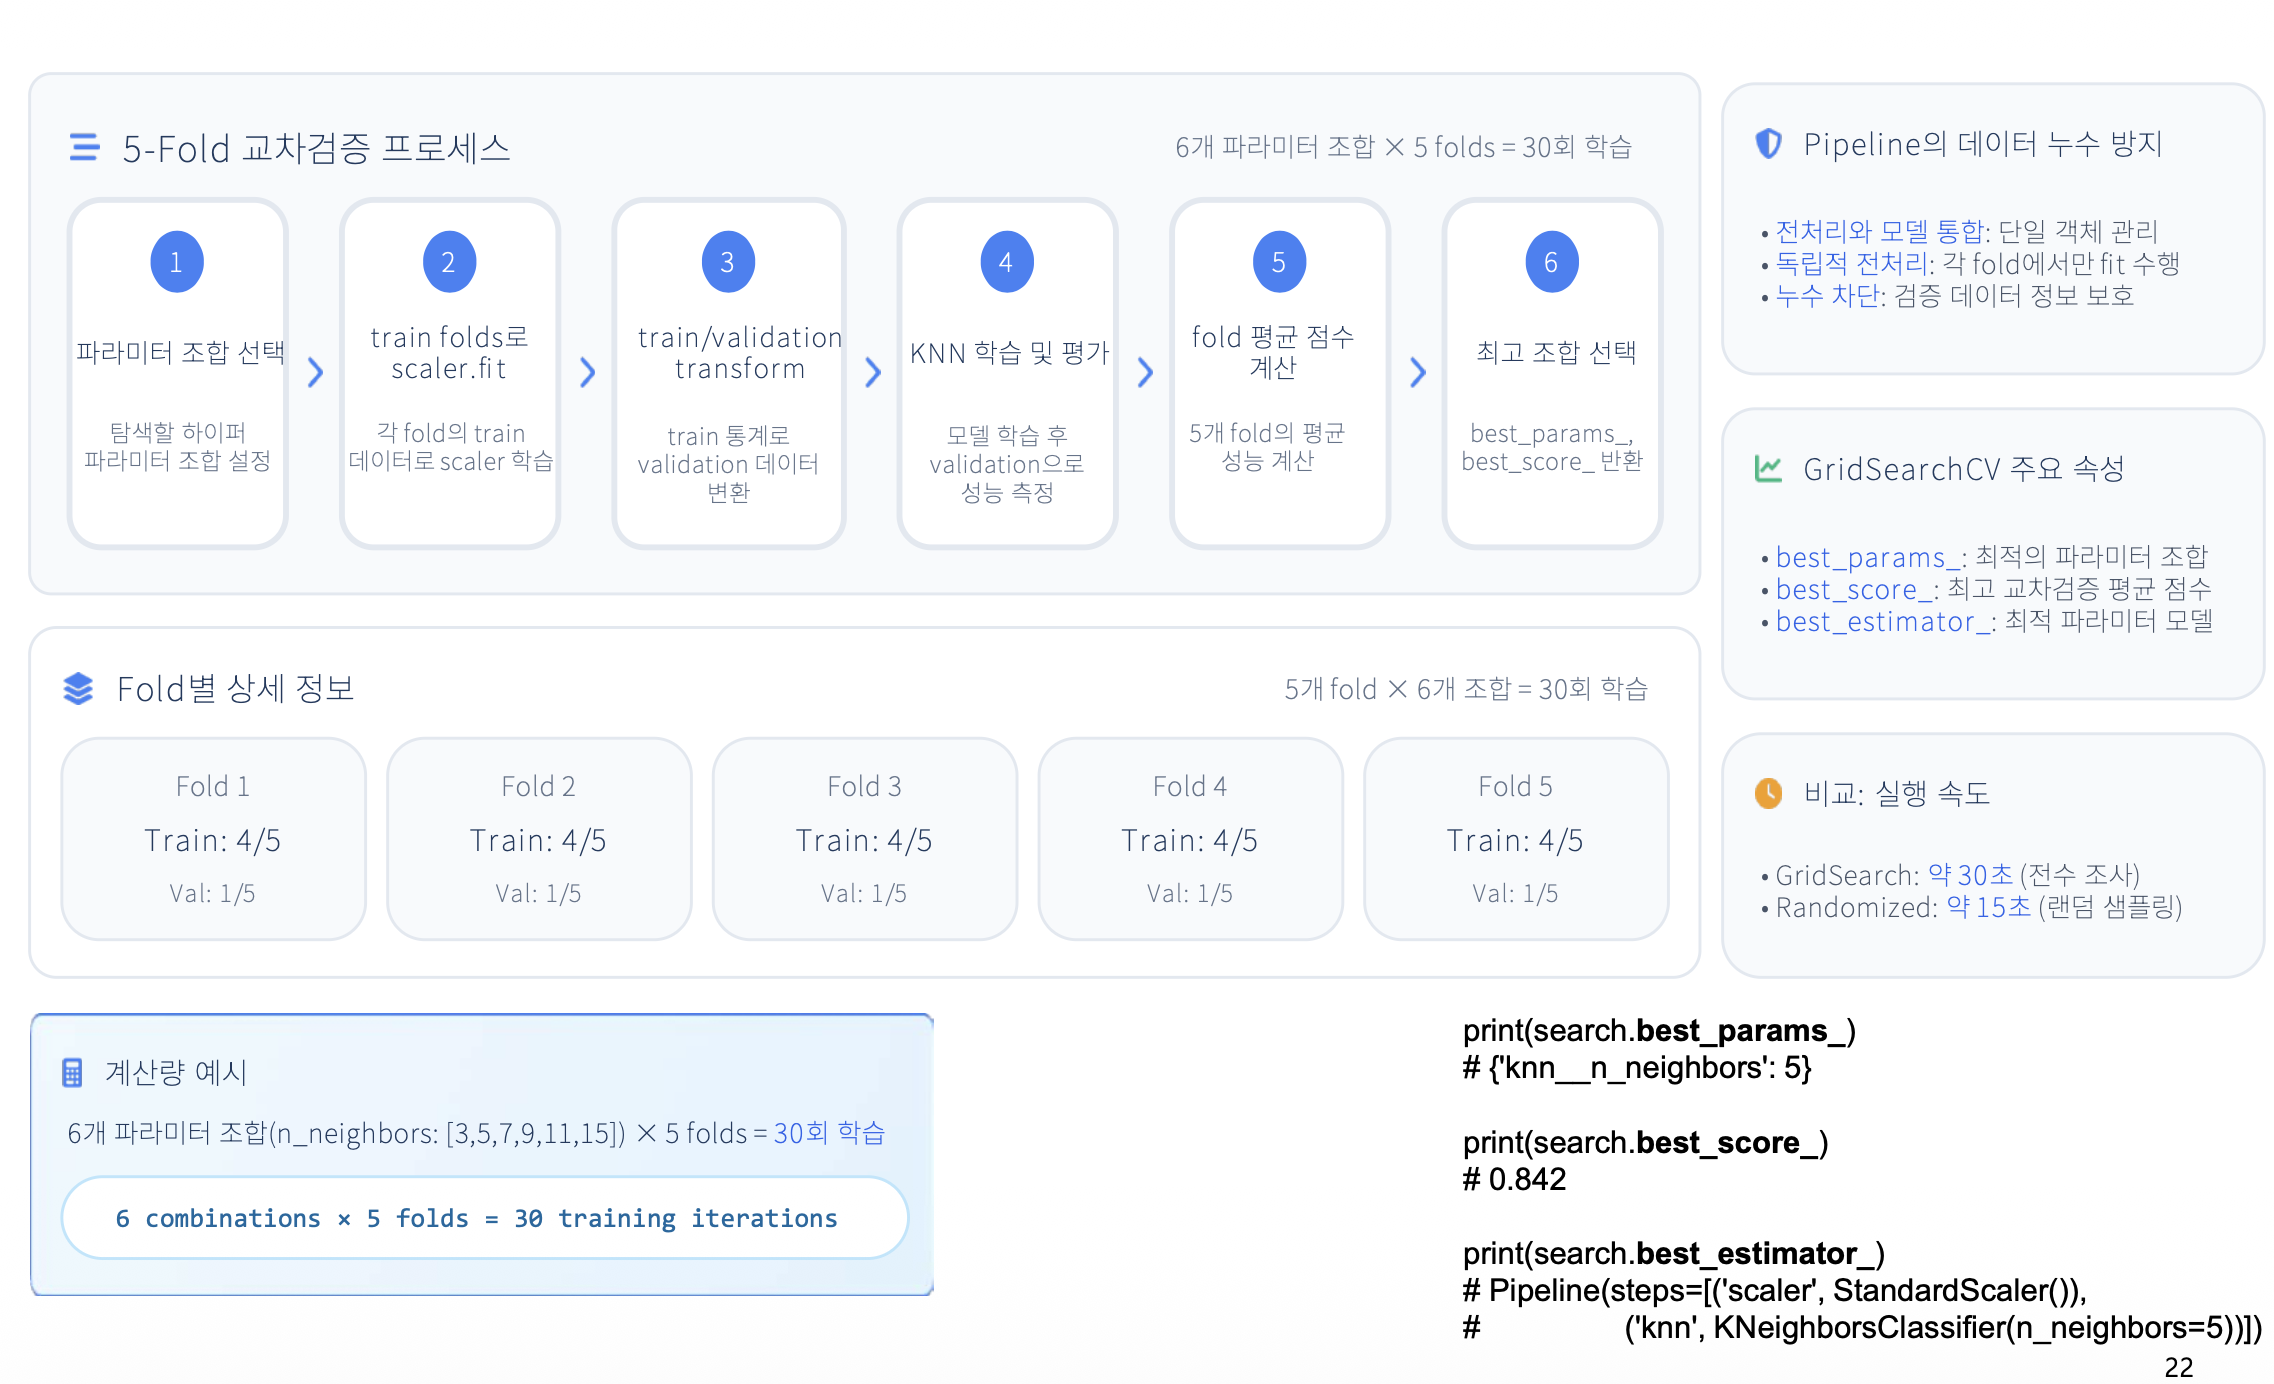

In [ ]:
pipe_knn = Pipeline([
    ("sclaer", StandardScaler()),,
    ('model', KNeighborsClassifier())
])

param_knn = {
    'model__n_neighbors': [3, 5, 7, 8],
    'model__weights': ['uniform', 'distance']
}

